In [82]:
import pandas as pd
import matplotlib.pyplot as plt
from ml_enhance import FeatureImportance
from collections import defaultdict
from pathlib import Path
import numpy as np
import json

In [32]:
df_baseline = pd.read_csv(r"..\data\chemprop_results\1_chemprop_no_added_w_charge_rerun_SHAP_results.csv")
df_full = pd.read_csv(r"..\data\chemprop_results\1_chemprop_full_feat_rerun_SHAP_results.csv")
df_rdkit = pd.read_csv(r"..\data\chemprop_results\1_chemprop_w_rdkit_rerun_SHAP_results.csv")

In [33]:
drop_formal_charge = True
frequency: dict[str, int] = defaultdict(int)
importance_dict: dict[str, list[float]] = defaultdict(list)

In [132]:
df_baseline

,fold_id,size,feature,mean_abs_shap,std_abs_shap
0,0,1.0,in_ring?,0.763635,0.572793
1,0,1.0,bond_type,0.637436,0.170127
2,0,1.0,degree,0.625918,0.228206
3,0,1.0,stereochemistry,0.477185,0.159445
4,0,1.0,atomic_number,0.442374,0.343097
...,...,...,...,...,...
295,9,1.0,stereochemistry,0.113261,0.092456
296,9,1.0,aromaticity,0.112842,0.161576
297,9,1.0,formal_charge,0.080563,0.083986
298,9,1.0,mass,0.068730,0.048317


In [47]:
importance_baseline = FeatureImportance(df_baseline)
_ = importance_baseline.get_FI_from_shap(drop_formal_charge=False, num_features=30)

importance_full = FeatureImportance(df_full)
_ = importance_full.get_FI_from_shap(drop_formal_charge=True, num_features=30)

importance_rdkit = FeatureImportance(df_rdkit)
_ = importance_rdkit.get_FI_from_shap(drop_formal_charge=True, num_features=30)

In [48]:
n_feat = 30

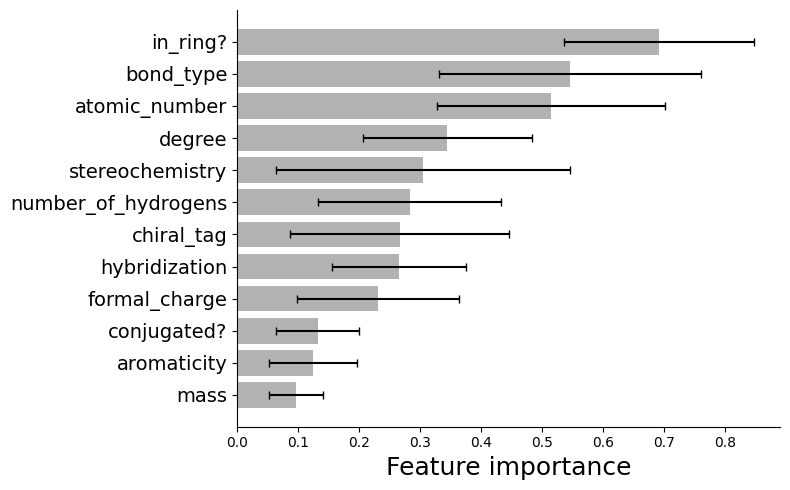

In [49]:
fig, ax = plt.subplots(figsize=(8, 5))
importance_baseline.plot(ax, n_feat)


plt.tight_layout()

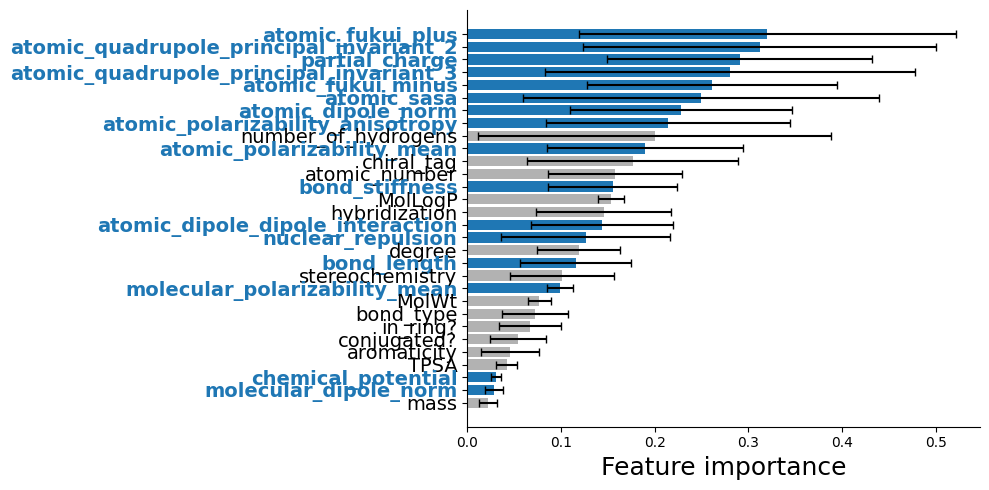

In [50]:
fig, ax = plt.subplots(figsize=(10, 5))
importance_full.plot(ax, n_feat)

plt.tight_layout()

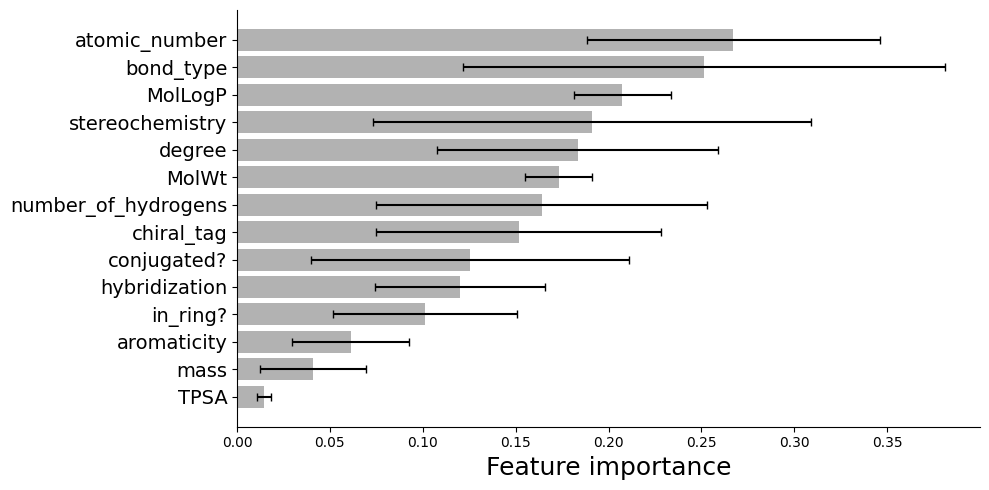

In [51]:
fig, ax = plt.subplots(figsize=(10, 5))
importance_rdkit.plot(ax, n_feat)

plt.tight_layout()

In [ ]:
input_path = Path(r"C:\Users\thibo\Downloads\hpc_results\1_chemprop_w_rdkit_rerun")

shap_files = [file for file in input_path.glob("*SHAP*") if file.is_file()]

In [135]:
groups = {
    "bond": ["bond_type", "conjugated?", "in_ring?", "stereochemistry"],
    "atom": ["atomic_number", "degree", "formal_charge", "chiral_tag", "number_of_hydrogens", "hybridization", "aromaticity", "mass"],
}

In [170]:
combined_df = pd.DataFrame()

for idx, file in enumerate(shap_files, start=1):
    with file.open("r") as f:
        data = json.load(f)
    
    df = pd.DataFrame(data["shap_values"], columns=data["feature_names"]).abs()

    new_df = pd.DataFrame()
    for key, vals in groups.items():
        new_df[key] = df[vals].mean(axis=1)

        df = df.drop(vals, axis=1)

    if len(df) > 0:
        new_df = pd.concat([new_df, df], axis=1)

    new_df = new_df.agg(["mean"], axis=0).T
    new_df = new_df.reset_index().rename({"index": "feature", "mean": "mean_abs_shap"}, axis=1)
    new_df.insert(0, "fold_id", idx)
    new_df.insert(1, "size", 1.0)

    combined_df = pd.concat(
        [combined_df, new_df]
    )
    
combined_df

,fold_id,size,feature,mean_abs_shap
0,1,1.0,bond,0.138072
1,1,1.0,atom,0.139745
2,1,1.0,TPSA,0.013975
3,1,1.0,MolLogP,0.206552
4,1,1.0,MolWt,0.186279
...,...,...,...,...
0,25,1.0,bond,0.188964
1,25,1.0,atom,0.134888
2,25,1.0,TPSA,0.011373
3,25,1.0,MolLogP,0.175400


In [171]:
importance_tst = FeatureImportance(combined_df)
_ = importance_tst.get_FI_from_shap(drop_formal_charge=False, num_features=30)

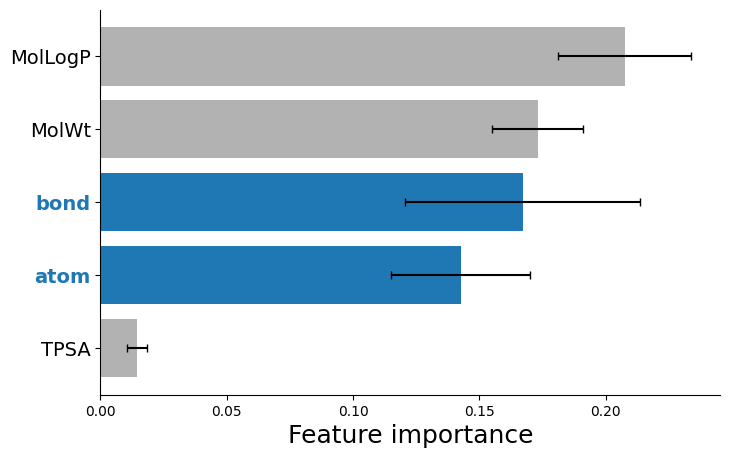

In [172]:
fig, ax = plt.subplots(figsize=(8, 5))

importance_tst.plot(ax, 20)